# CS611 Assignment 1 - Exploratory Data Analysis

Goal: understand the four raw sources well enough to design defensible bronze/silver/gold layers and to call out any data leakage risks before we hand a feature store to the model team.

**Sources**
- `data/lms_loan_daily.csv` &mdash; one row per (loan, snapshot_date). Feeds the **label store**.
- `data/feature_clickstream.csv` &mdash; 20 numeric behavioural features per (Customer_ID, snapshot_date).
- `data/features_attributes.csv` &mdash; demographics, one row per customer.
- `data/features_financials.csv` &mdash; financial profile, one row per customer.

Run this notebook from the project root so the relative `data/` paths resolve.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 1. Inventory each source

In [2]:
sources = {
    'lms_loan_daily':     'data/lms_loan_daily.csv',
    'feature_clickstream':'data/feature_clickstream.csv',
    'features_attributes':'data/features_attributes.csv',
    'features_financials':'data/features_financials.csv',
}
raw = {name: pd.read_csv(path) for name, path in sources.items()}
summary = pd.DataFrame([
    {
        'source': name,
        'rows': len(df),
        'cols': df.shape[1],
        'unique_customers': df['Customer_ID'].nunique() if 'Customer_ID' in df.columns else None,
        'unique_snapshots': df['snapshot_date'].nunique() if 'snapshot_date' in df.columns else None,
        'date_min': df['snapshot_date'].min() if 'snapshot_date' in df.columns else None,
        'date_max': df['snapshot_date'].max() if 'snapshot_date' in df.columns else None,
    } for name, df in raw.items()
])
summary

,source,rows,cols,unique_customers,unique_snapshots,date_min,date_max
0,lms_loan_daily,137500,11,12500,35,2023-01-01,2025-11-01
1,feature_clickstream,215376,22,8974,24,2023-01-01,2024-12-01
2,features_attributes,12500,6,12500,25,2023-01-01,2025-01-01
3,features_financials,12500,22,12500,25,2023-01-01,2025-01-01


Key observation: `features_attributes` and `features_financials` only have **one snapshot per customer** &mdash; they act as slowly-changing dimensions. `feature_clickstream` and `lms_loan_daily` are time-series tables.

Design implication: in gold we drive the join from clickstream (monthly cadence per customer) and left-join the static tables on `Customer_ID`.

## 2. LMS loan daily &mdash; what does the label look like?

In [3]:
lms = raw['lms_loan_daily'].copy()
lms['snapshot_date'] = pd.to_datetime(lms['snapshot_date'])
lms['loan_start_date'] = pd.to_datetime(lms['loan_start_date'])
lms['mob'] = lms['installment_num']
lms['installments_missed'] = np.ceil(lms['overdue_amt'] / lms['due_amt'].replace(0, np.nan)).fillna(0).astype(int)
lms.loc[lms['overdue_amt'] == 0, 'installments_missed'] = 0
lms['dpd'] = np.where(
    lms['overdue_amt'] > 0,
    (lms['snapshot_date'] - (lms['snapshot_date'] - pd.to_timedelta(lms['installments_missed'] * 30, unit='D'))).dt.days,
    0
)
lms[['loan_id','Customer_ID','mob','due_amt','overdue_amt','dpd']].head()

,loan_id,Customer_ID,mob,due_amt,overdue_amt,dpd
0,CUS_0x1000_2023_05_01,CUS_0x1000,0,0.0,0.0,0
1,CUS_0x1000_2023_05_01,CUS_0x1000,1,1000.0,0.0,0
2,CUS_0x1000_2023_05_01,CUS_0x1000,2,1000.0,0.0,0
3,CUS_0x1000_2023_05_01,CUS_0x1000,3,1000.0,1000.0,30
4,CUS_0x1000_2023_05_01,CUS_0x1000,4,1000.0,0.0,0


In [4]:
# Label = 1 if DPD >= 30 at MOB 6
labels = lms[lms['mob'] == 6].copy()
labels['label'] = (labels['dpd'] >= 30).astype(int)
print('Label cohort size:', len(labels))
print('Default rate:', labels['label'].mean().round(3))
labels.groupby(labels['snapshot_date'].dt.to_period('M'))['label'].agg(['count','mean']).head(12)

Label cohort size: 12500
Default rate: 0.288


,count,mean
snapshot_date,,
2023-07,530,0.264151
2023-08,501,0.307385
2023-09,506,0.320158
2023-10,510,0.268627
2023-11,521,0.266795
2023-12,517,0.264990
2024-01,471,0.297240
2024-02,481,0.288981
2024-03,454,0.262115


**Leakage warning** &mdash; columns in this table that *must not* appear in the feature store: `loan_id`, `loan_start_date`, `due_amt`, `paid_amt`, `overdue_amt`, `balance`, `dpd`, `installments_missed`, `mob`, `label`. They are either the target itself or future information not available at loan application.

## 3. Clickstream &mdash; numeric, low cleaning needed

In [5]:
click = raw['feature_clickstream']
print(click.dtypes)
print('Nulls:', click.isnull().sum().sum())
fe_cols = [c for c in click.columns if c.startswith('fe_')]
click[fe_cols].describe().T[['mean','std','min','max']]

fe_1              int64
fe_2              int64
fe_3              int64
fe_4              int64
fe_5              int64
fe_6              int64
fe_7              int64
fe_8              int64
fe_9              int64
fe_10             int64
fe_11             int64
fe_12             int64
fe_13             int64
fe_14             int64
fe_15             int64
fe_16             int64
fe_17             int64
fe_18             int64
fe_19             int64
fe_20             int64
Customer_ID      object
snapshot_date    object
dtype: object
Nulls: 0


,mean,std,min,max
fe_1,101.414796,99.833594,-378.0,541.0
fe_2,103.096195,99.930002,-356.0,560.0
fe_3,104.333709,100.599865,-399.0,583.0
fe_4,105.648503,100.326065,-307.0,562.0
fe_5,106.996676,100.693607,-343.0,570.0
fe_6,103.235922,100.270388,-321.0,565.0
fe_7,107.070337,100.323265,-368.0,537.0
fe_8,110.718724,100.243698,-361.0,573.0
fe_9,114.406354,100.186139,-328.0,577.0
fe_10,117.775797,100.807686,-317.0,537.0


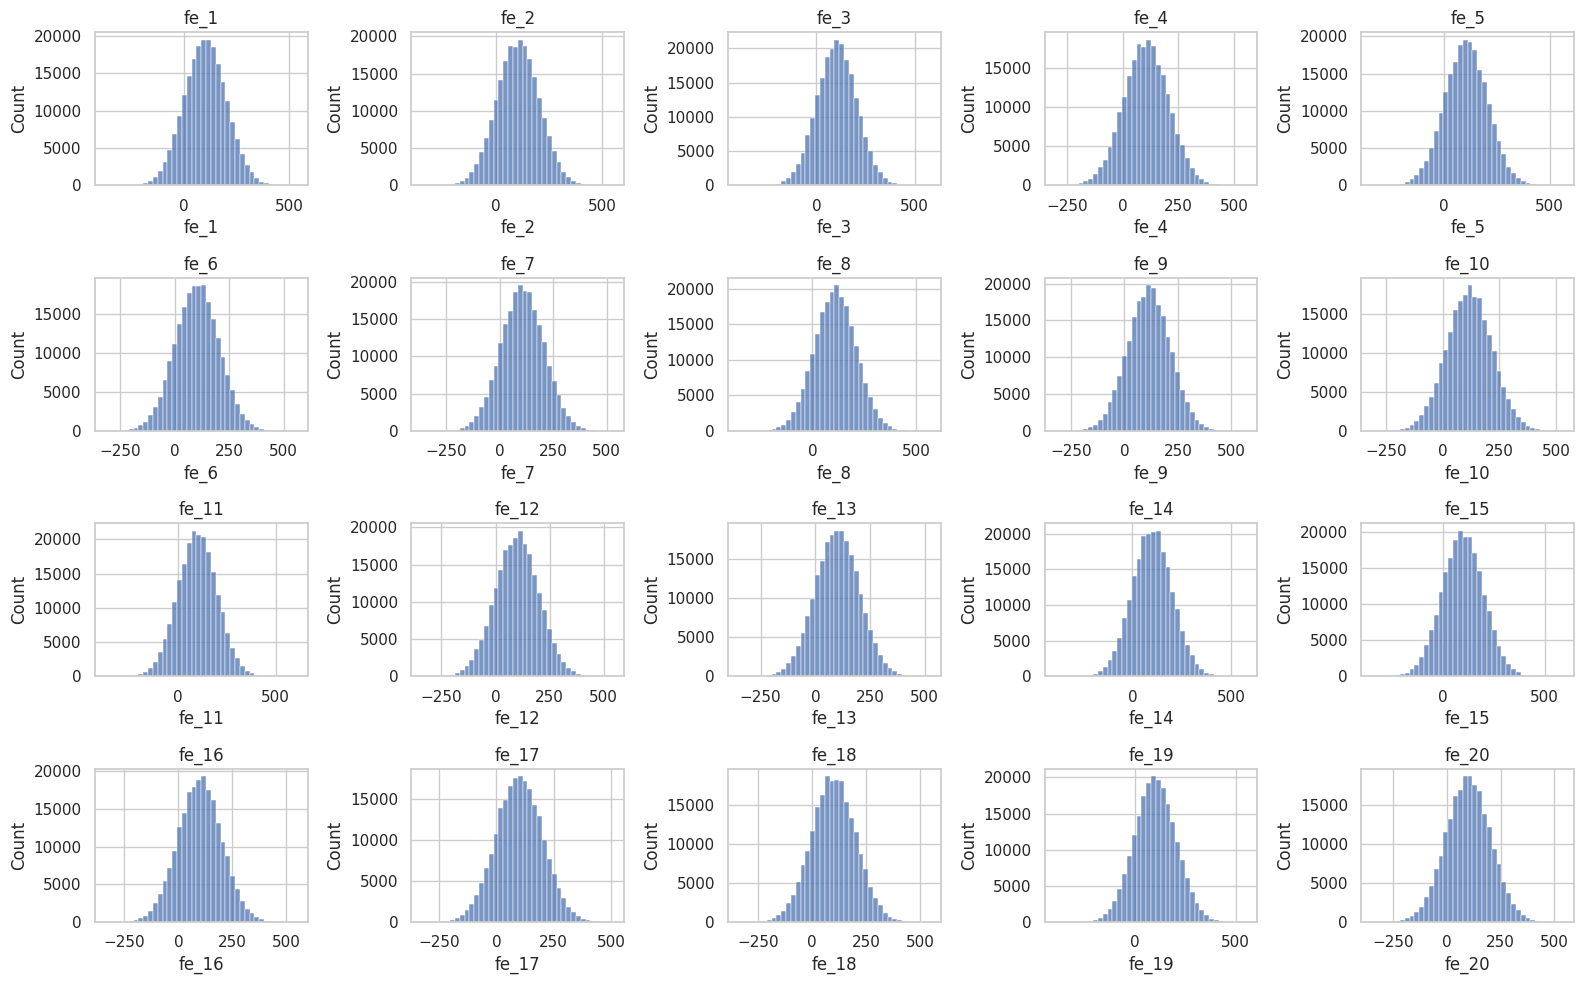

In [6]:
fig, ax = plt.subplots(4, 5, figsize=(16, 10))
for i, c in enumerate(fe_cols):
    sns.histplot(click[c], ax=ax.flat[i], bins=40, kde=False)
    ax.flat[i].set_title(c)
plt.tight_layout()
plt.show()

Distributions are roughly symmetric around zero &mdash; looks like standardised behavioural embeddings. Silver layer just needs to enforce integer types and snapshot_date casting.

## 4. Attributes &mdash; PII + dirty Age field

In [7]:
attr = raw['features_attributes']
attr.head()

,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x1000,Alistair Barrf,18,913-74-1218,Lawyer,2023-05-01
1,CUS_0x1009,Arunah,26,063-67-6938,Mechanic,2025-01-01
2,CUS_0x100b,Shirboni,19,#F%$D@*&8,Media_Manager,2024-03-01
3,CUS_0x1011,Schneyerh,44,793-05-8223,Doctor,2023-11-01
4,CUS_0x1013,Cameront,44,930-49-9615,Mechanic,2023-12-01


In [8]:
# Age arrives as string with trailing '_' on some rows
bad_age = attr[attr['Age'].astype(str).str.contains(r'[^0-9]', regex=True)]
print('Dirty Age rows:', len(bad_age))
print(bad_age['Age'].value_counts().head(10))
print()
print('Occupation values:')
print(attr['Occupation'].value_counts().head(20))

Dirty Age rows: 741
Age
-500    104
32_      25
39_      25
29_      23
24_      23
21_      23
43_      21
28_      20
22_      20
45_      19
Name: count, dtype: int64

Occupation values:
Occupation
_______          880
Lawyer           828
Architect        795
Engineer         793
Accountant       791
Scientist        789
Teacher          782
Media_Manager    780
Mechanic         780
Developer        780
Entrepreneur     776
Journalist       761
Doctor           760
Musician         741
Manager          736
Writer           728
Name: count, dtype: int64


Silver cleaning rules:
- Strip non-digit characters from `Age`, cast to int, null-out values <= 0 or > 100.
- Replace `Occupation == '_______'` with NULL.
- **Drop `Name` and `SSN`** &mdash; direct PII and not predictive.

## 5. Financials &mdash; the messiest table

In [9]:
fin = raw['features_financials']
fin.dtypes

Customer_ID                  object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
snapshot_date                object
dtype: object

In [10]:
# Numeric columns that arrive as strings due to trailing '_' garbage:
dirty = ['Annual_Income','Num_of_Loan','Num_of_Delayed_Payment','Changed_Credit_Limit','Outstanding_Debt','Amount_invested_monthly','Monthly_Balance']
for c in dirty:
    n_dirty = fin[c].astype(str).str.contains('_').sum()
    print(f'{c}: {n_dirty} rows contain "_"')
print()
print('Credit_Mix values:', fin['Credit_Mix'].value_counts().to_dict())
print('Payment_of_Min_Amount values:', fin['Payment_of_Min_Amount'].value_counts().to_dict())
print('Sample Credit_History_Age values:', fin['Credit_History_Age'].dropna().sample(5, random_state=1).tolist())

Annual_Income: 859 rows contain "_"
Num_of_Loan: 623 rows contain "_"
Num_of_Delayed_Payment: 374 rows contain "_"
Changed_Credit_Limit: 254 rows contain "_"
Outstanding_Debt: 139 rows contain "_"
Amount_invested_monthly: 558 rows contain "_"
Monthly_Balance: 1 rows contain "_"

Credit_Mix values: {'Standard': 4497, 'Good': 3032, '_': 2611, 'Bad': 2360}
Payment_of_Min_Amount values: {'Yes': 6571, 'No': 4491, 'NM': 1438}
Sample Credit_History_Age values: ['15 Years and 0 Months', '25 Years and 6 Months', '9 Years and 4 Months', '6 Years and 4 Months', '30 Years and 1 Months']


Silver cleaning rules summarised:
- Strip `'_'` from the 7 numeric strings then cast to float.
- `Credit_Mix == '_'` &rarr; NULL.
- `Payment_of_Min_Amount == 'NM'` &rarr; NULL (NM = no-match placeholder).
- Parse `Credit_History_Age` ("X Years and Y Months") &rarr; integer `Credit_History_Months`.
- `Type_of_Loan` is free-text list; keep a derived `Num_Loan_Types_Listed` count and drop the raw text in gold.
- Clamp `Num_Bank_Accounts`, `Num_Credit_Card`, `Num_of_Loan`, `Interest_Rate` to plausible ranges.

## 6. Feature design choices for gold

**One wide feature table** keyed on `(Customer_ID, snapshot_date)`:
1. Clickstream silver is the spine (monthly, full customer coverage).
2. LEFT JOIN attributes (Customer_ID only &mdash; slowly-changing).
3. LEFT JOIN financials (Customer_ID only &mdash; slowly-changing).
4. Engineered features: `income_to_debt_ratio`, `emi_burden`, `Credit_History_Months`, `Num_Loan_Types_Listed`.
5. Impute numerics with 0 and categoricals with `'Unknown'` (silver keeps true NULLs so other consumers can choose).
6. Drop direct PII and all loan-outcome columns &mdash; the gold feature processor asserts this invariant at the end.

**Why a single wide table?** Easiest to consume for the downstream classification model and avoids re-joining on every training run. The trade-off is wider rows; with 46 columns and ~9k customers per snapshot it is comfortably within Spark/parquet limits.

## 7. ML sanity check (run after `python main.py`)

After the pipeline has produced `datamart/gold/feature_store/` and `datamart/gold/label_store/`, the following block joins them and trains a logistic regression. We expect a modest, *non-perfect* AUC &mdash; a perfect AUC would be a red flag for leakage.

In [11]:
import glob, os
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('eda_ml').master('local[*]') \
    .config('spark.driver.host','127.0.0.1') \
    .config('spark.driver.bindAddress','127.0.0.1').getOrCreate()
spark.sparkContext.setLogLevel('ERROR')

fs = spark.read.parquet(*glob.glob('datamart/gold/feature_store/*'))
ls = spark.read.parquet(*glob.glob('datamart/gold/label_store/*'))
joined = ls.join(fs, on=['Customer_ID','snapshot_date'], how='inner').toPandas()
print('joined rows:', len(joined), '| default rate:', round(joined['label'].mean(), 3))

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

feat_cols = [c for c in joined.columns if c.startswith('fe_')] + [
    'Age','Annual_Income','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate','Num_of_Loan',
    'Delay_from_due_date','Num_of_Delayed_Payment','Changed_Credit_Limit','Num_Credit_Inquiries',
    'Outstanding_Debt','Credit_Utilization_Ratio','Total_EMI_per_month','Amount_invested_monthly',
    'Monthly_Balance','Credit_History_Months','Num_Loan_Types_Listed','income_to_debt_ratio','emi_burden'
]
X = joined[feat_cols].fillna(0).values
y = joined['label'].values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
sc = StandardScaler().fit(Xtr)
m = LogisticRegression(max_iter=2000).fit(sc.transform(Xtr), ytr)
print('Train AUC:', round(roc_auc_score(ytr, m.predict_proba(sc.transform(Xtr))[:,1]), 3))
print('Test  AUC:', round(roc_auc_score(yte, m.predict_proba(sc.transform(Xte))[:,1]), 3))

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/18 05:51:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

joined rows: 8974 | default rate: 0.289
Train AUC: 0.652
Test  AUC: 0.636


26/05/18 11:51:58 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:123)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:688)
	at org.apache.spark.storage.BlockManagerMasterE